# Compare peak identification results between different peakID attempts and rank specimens for similarity

Author: **Niels J. de Winter** (*n.j.de.winter@vu.nl*)<br>
Assistant Professor Vrije Universiteit Amsterdam

In [1]:
# Load necessary packages
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd

# Load data

In [2]:
# Load growth interval and peak depth data
Depth_data = pd.read_csv("Depth_values_intervals_peaks.csv")
print(Depth_data.head())

                  file specimen   treatment    peakID peak_interval  \
0  B255_int_peakid.csv     B255  intertidal  peakID_1    interval 7   
1  B255_int_peakid.csv     B255  intertidal  peakID_1        peak 7   
2  B255_int_peakid.csv     B255  intertidal  peakID_1    interval 6   
3  B255_int_peakid.csv     B255  intertidal  peakID_1        peak 6   
4  B255_int_peakid.csv     B255  intertidal  peakID_1        peak 5   

         depth  
0     0.445779  
1   942.656105  
2  1042.747005  
3  2011.904387  
4  2431.265151  


# Calculate the similarity between peakID attempts

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18],
 [Text(0, 0, 'G723'),
  Text(1, 0, 'B325'),
  Text(2, 0, 'G767'),
  Text(3, 0, 'B323'),
  Text(4, 0, 'G719'),
  Text(5, 0, 'G668'),
  Text(6, 0, 'G728'),
  Text(7, 0, 'G730'),
  Text(8, 0, 'G717'),
  Text(9, 0, 'G691'),
  Text(10, 0, 'G664'),
  Text(11, 0, 'G737'),
  Text(12, 0, 'G781'),
  Text(13, 0, 'G732'),
  Text(14, 0, 'B255'),
  Text(15, 0, 'G753'),
  Text(16, 0, 'G770'),
  Text(17, 0, 'G779'),
  Text(18, 0, 'G652')])

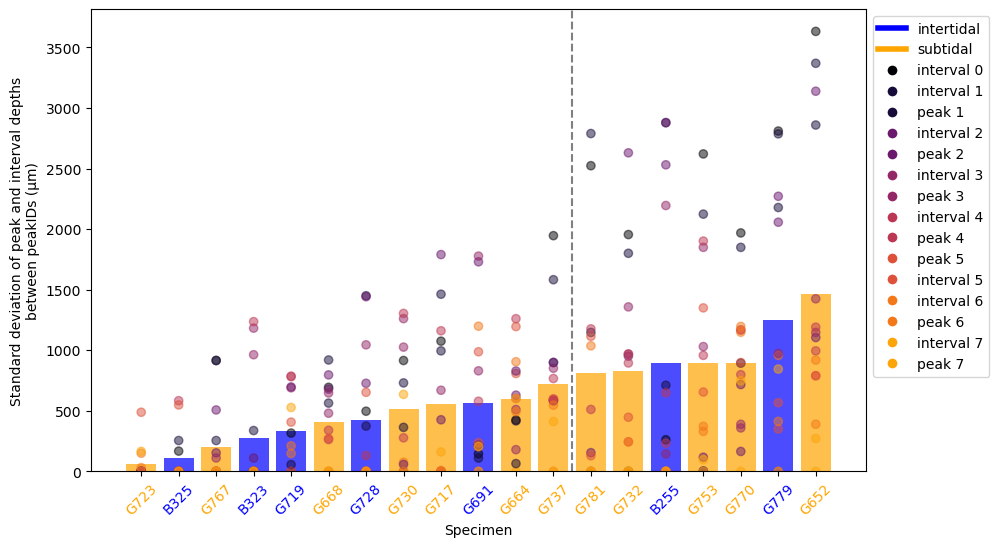

In [11]:
# Calculate statistics on transition depths
spread_stats = Depth_data.groupby(['specimen', 'treatment', 'peak_interval'])['depth'].agg(['min', 'max', 'mean', 'std']).reset_index()
# Summarize standard deviation of transition depths per specimen
std_summary = spread_stats.groupby(['specimen', 'treatment'])['std'].agg(['mean', 'std']).reset_index()

# Sort std_summary by mean standard deviation
std_summary_sorted = std_summary.sort_values('mean')

# Plot mean standard deviation of transition depths per specimen
# Create color mapping for treatments
treatment_color_map = {'intertidal': 'blue', 'subtidal': 'orange'}
treatment_colors = [treatment_color_map[treatment] for treatment in std_summary_sorted['treatment']]

# Create color scale for number of peak/interval in scatter plot
peak_intervals = sorted(spread_stats['peak_interval'].unique(), key=lambda x: int(x.split()[-1]))
peak_color_map = {
    'peak 0': plt.cm.inferno(0),
    'interval 0': plt.cm.inferno(0),
    'peak 1': plt.cm.inferno(0.1),
    'interval 1': plt.cm.inferno(0.1),
    'peak 2': plt.cm.inferno(0.3),
    'interval 2': plt.cm.inferno(0.3),
    'peak 3': plt.cm.inferno(0.4),
    'interval 3': plt.cm.inferno(0.4),
    'peak 4': plt.cm.inferno(0.5),
    'interval 4': plt.cm.inferno(0.5),
    'peak 5': plt.cm.inferno(0.6),
    'interval 5': plt.cm.inferno(0.6),
    'peak 6': plt.cm.inferno(0.7),
    'interval 6': plt.cm.inferno(0.7),
    'peak 7': plt.cm.inferno(0.8),
    'interval 7': plt.cm.inferno(0.8)
}

plt.figure(figsize=(10, 6))
plt.bar(std_summary_sorted['specimen'], std_summary_sorted['mean'], color=treatment_colors, alpha=0.7)
plt.scatter(spread_stats['specimen'], spread_stats['std'], color=[peak_color_map[pi] for pi in spread_stats['peak_interval']], alpha=0.5)
plt.xlabel('Specimen')
plt.ylabel('Standard deviation of peak and interval depths\nbetween peakIDs (mm)')
plt.xticks(rotation=45)
# Color the tick labels
for ticklabel, color in zip(plt.gca().get_xticklabels(), treatment_colors):
    ticklabel.set_color(color)
# Add legend for treatments
legend_elements = [Line2D([0], [0], color='blue', lw=4, label='intertidal'),
                   Line2D([0], [0], color='orange', lw=4, label='subtidal')]
plt.legend(handles=legend_elements, loc='upper left')
# Add legend for peak/interval colors
peak_legend_elements = [Line2D([0], [0], marker='o', color='w', label=pi, markerfacecolor=peak_color_map[pi], markersize=8) for pi in peak_intervals]
plt.legend(handles=legend_elements + peak_legend_elements, loc='upper left', bbox_to_anchor=(1, 1))
# Add dashed vertical line between specimen G737 and G781
plt.axvline(x=11.5, color='gray', linestyle='--')
# plt.axvline(x=std_summary_sorted[std_summary_sorted['specimen'] == 'G781'].index[0] + 0.5, color='gray', linestyle='--')
plt.ylabel('Standard deviation of peak and interval depths\nbetween peakIDs (μm)')
plt.xticks(rotation=45)

In [55]:
print(peak_intervals)

['interval 0', 'interval 1', 'peak 1', 'interval 2', 'peak 2', 'interval 3', 'peak 3', 'interval 4', 'peak 4', 'peak 5', 'interval 5', 'interval 6', 'peak 6', 'interval 7', 'peak 7']
